In [1]:
url = "https://raw.githubusercontent.com/tidyverts/tsibbledata/master/data-raw/vic_elec/VIC2015/demand.csv"
df = pd.read_csv(url)
df

NameError: name 'pd' is not defined

In [ ]:
df["Date"] = df["Date"].apply(
    lambda x: pd.Timestamp("1899-12-30") + pd.Timedelta(x, unit="days")
)
df["ds"] = df["Date"] + pd.to_timedelta((df["Period"] - 1) * 30, unit="m")

In [ ]:
timeseries = df[["ds", "OperationalLessIndustrial"]]
timeseries.columns = [
    "ds",
    "y",
]  # Rename to OperationalLessIndustrial to y for simplicity.

# Filter for first 149 days of 2012.
start_date = pd.to_datetime("2012-01-01")
end_date = start_date + pd.Timedelta("149D")
mask = (timeseries["ds"] >= start_date) & (timeseries["ds"] < end_date)
timeseries = timeseries[mask]

# Resample to hourly
timeseries = timeseries.set_index("ds").resample("h").sum()

# Split data into training and testing sets
test_size = 24 * 7 * 2 # 2 weeks for testing (hourly data)
train_data = timeseries.iloc[:-test_size]
test_data = timeseries.iloc[-test_size:]

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)
display(train_data.head())
display(test_data.head())

Training data shape: (3240, 1)
Testing data shape: (336, 1)


,y
ds,
2012-01-01 00:00:00,7926.529376
2012-01-01 01:00:00,7901.826990
2012-01-01 02:00:00,7255.721350
2012-01-01 03:00:00,6792.503352
2012-01-01 04:00:00,6635.984460


,y
ds,
2012-05-15 00:00:00,8821.939726
2012-05-15 01:00:00,8815.029322
2012-05-15 02:00:00,8157.569918
2012-05-15 03:00:00,7710.985372
2012-05-15 04:00:00,7637.993618


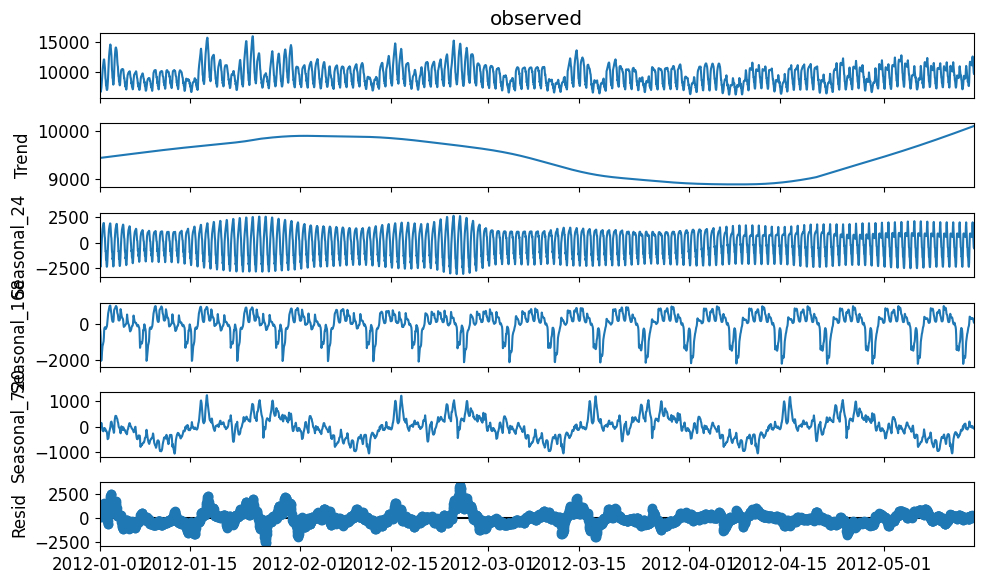

In [ ]:
mstl = MSTL(
    train_data["y"],
    periods=[24, 24 * 7, 720],
    iterate=3,
    stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0},
)
res = mstl.fit()  # Use .fit() to perform and return the decomposition
ax = res.plot()
plt.tight_layout()

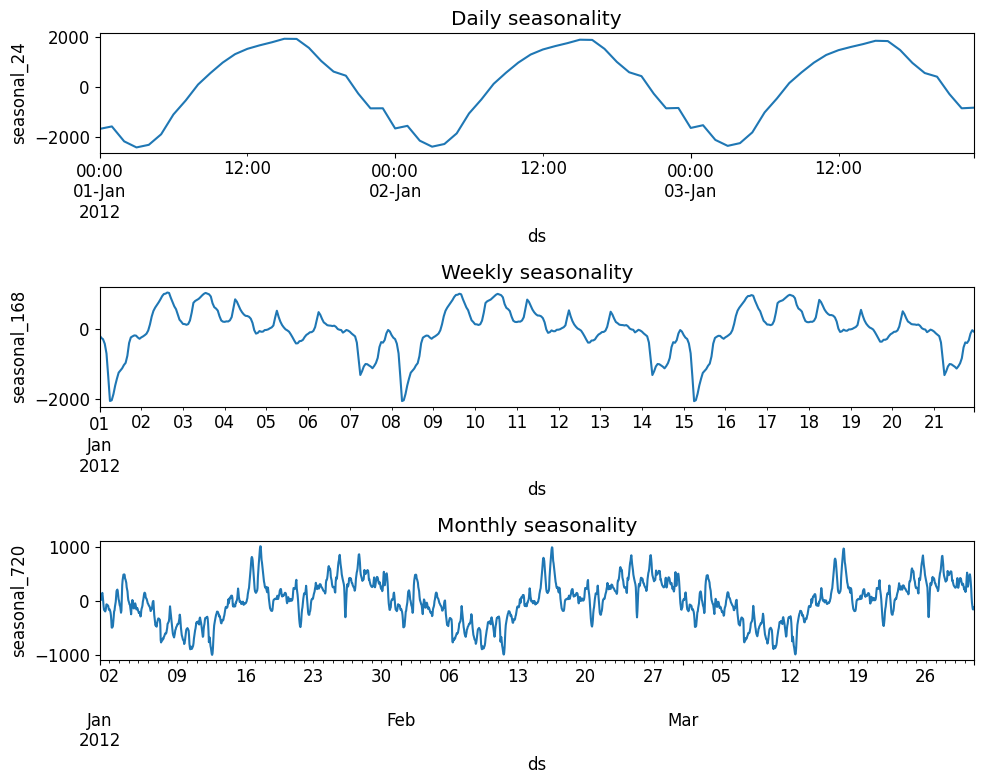

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=[10, 8])
res.seasonal["seasonal_24"].iloc[: 24 * 3].plot(ax=ax[0])
ax[0].set_ylabel("seasonal_24")
ax[0].set_title("Daily seasonality")

res.seasonal["seasonal_168"].iloc[: 24 * 7 * 3].plot(ax=ax[1])
ax[1].set_ylabel("seasonal_168")
ax[1].set_title("Weekly seasonality")

res.seasonal["seasonal_720"].iloc[: 24 * 30 * 3].plot(ax=ax[2])
ax[2].set_ylabel("seasonal_720")
ax[2].set_title("Monthly seasonality")

plt.tight_layout()
plt.savefig("all_seasonalities.png")

In [ ]:
original_variance = train_data['y'].var()

daily_seasonal_variance = res.seasonal['seasonal_24'].var()
weekly_seasonal_variance = res.seasonal['seasonal_168'].var()
monthly_seasonal_variance = res.seasonal['seasonal_720'].var()

print(f"Original time series variance (train data): {original_variance:.2f}")
print(f"Daily seasonality strength: {daily_seasonal_variance / original_variance:.4f}")
print(f"Weekly seasonality strength: {weekly_seasonal_variance / original_variance:.4f}")
print(f"Monthly seasonality strength: {monthly_seasonal_variance / original_variance:.4f}")

Original time series variance (train data): 3059748.42
Daily seasonality strength: 0.5616
Weekly seasonality strength: 0.1600
Monthly seasonality strength: 0.0576


### Forecasting with MSTL Components

To forecast, we'll individually forecast the trend and residuals, and extend the seasonal components by repeating their patterns. Then, we combine them to get the final forecast.

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing

# Define forecast horizon as the length of the test data
forecast_steps = len(test_data)

# Create a future date index for forecasting (aligns with test_data index)
future_dates = test_data.index

# 1. Forecast the Trend Component using Exponential Smoothing on training data
trend_model = ExponentialSmoothing(res.trend, trend='add', seasonal=None, initialization_method="estimated").fit()
forecasted_trend = trend_model.forecast(forecast_steps)

# 2. Forecast Seasonal Components by repeating the last cycle from training data
def repeat_seasonal(seasonal_component, steps, index):
    period = len(seasonal_component)
    repeated_seasonal = np.tile(seasonal_component, int(np.ceil(steps / period)))[:steps]
    return pd.Series(repeated_seasonal, index=index)

forecasted_seasonal_24 = repeat_seasonal(res.seasonal['seasonal_24'].iloc[-24:], forecast_steps, future_dates)
forecasted_seasonal_168 = repeat_seasonal(res.seasonal['seasonal_168'].iloc[-168:], forecast_steps, future_dates)
forecasted_seasonal_720 = repeat_seasonal(res.seasonal['seasonal_720'].iloc[-720:], forecast_steps, future_dates)

# 3. Forecast Residuals (assume 0 for simplicity, or model them if significant)
forecasted_residuals = pd.Series(0, index=future_dates)

# 4. Combine all components for the final forecast
final_forecast = forecasted_trend + forecasted_seasonal_24 + forecasted_seasonal_168 + forecasted_seasonal_720 + forecasted_residuals

print("Forecasted Trend (first 5):")
display(forecasted_trend.head())
print("Forecasted Daily Seasonality (first 5):")
display(forecasted_seasonal_24.head())
print("Final Forecast (first 5):")
display(final_forecast.head())

Forecasted Trend (first 5):


,0
2012-05-15 00:00:00,10102.090761
2012-05-15 01:00:00,10104.178202
2012-05-15 02:00:00,10106.265643
2012-05-15 03:00:00,10108.353085
2012-05-15 04:00:00,10110.440526


Forecasted Daily Seasonality (first 5):


,0
ds,
2012-05-15 00:00:00,-1334.230585
2012-05-15 01:00:00,-1319.407544
2012-05-15 02:00:00,-1889.743341
2012-05-15 03:00:00,-2296.294857
2012-05-15 04:00:00,-2374.240767


Final Forecast (first 5):


,0
2012-05-15 00:00:00,8744.731028
2012-05-15 01:00:00,8775.008715
2012-05-15 02:00:00,8249.216878
2012-05-15 03:00:00,7868.217270
2012-05-15 04:00:00,7928.079145


### Visualize Original, Decomposed, and Forecasted Series

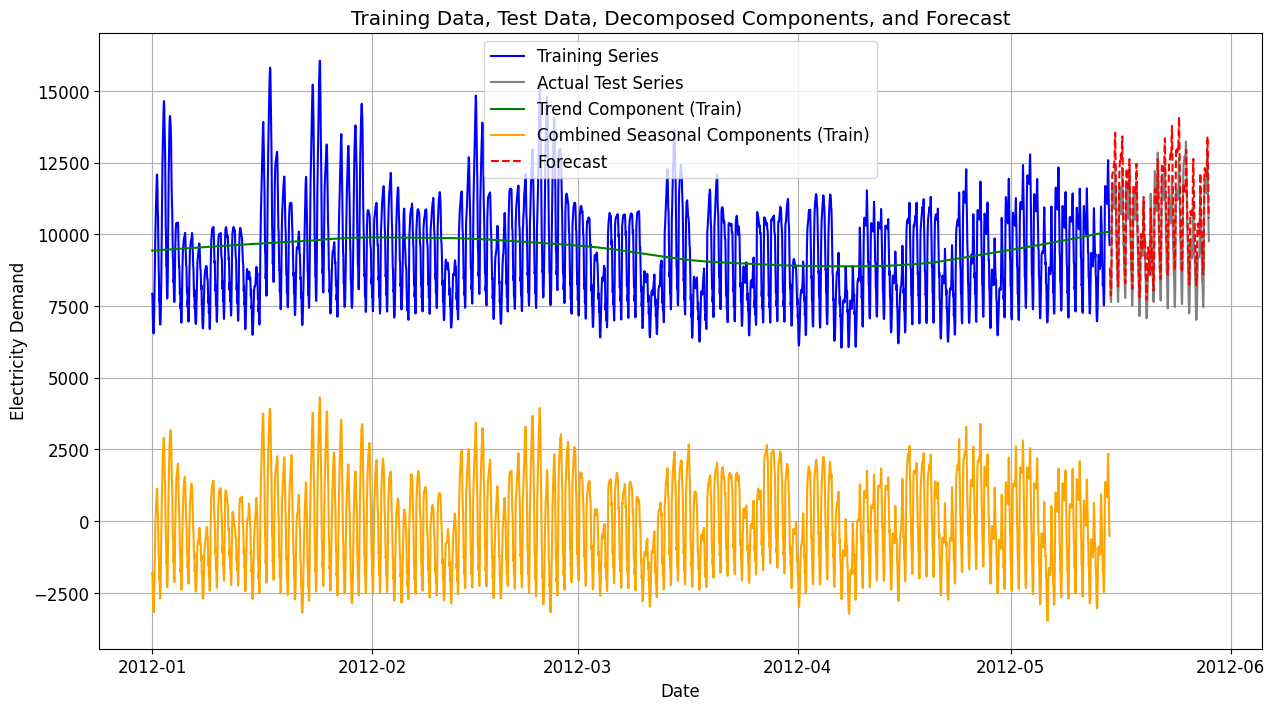

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(train_data.index, train_data['y'], label='Training Series', color='blue')
plt.plot(test_data.index, test_data['y'], label='Actual Test Series', color='gray')
plt.plot(res.trend.index, res.trend, label='Trend Component (Train)', color='green')

# Plot the combined seasonal components
combined_seasonal = res.seasonal['seasonal_24'] + res.seasonal['seasonal_168'] + res.seasonal['seasonal_720']
plt.plot(combined_seasonal.index, combined_seasonal, label='Combined Seasonal Components (Train)', color='orange')

plt.plot(future_dates, final_forecast, label='Forecast', color='red', linestyle='--')

plt.title('Training Data, Test Data, Decomposed Components, and Forecast')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True)
plt.show()

### Detailed Forecast vs. Actual Plot

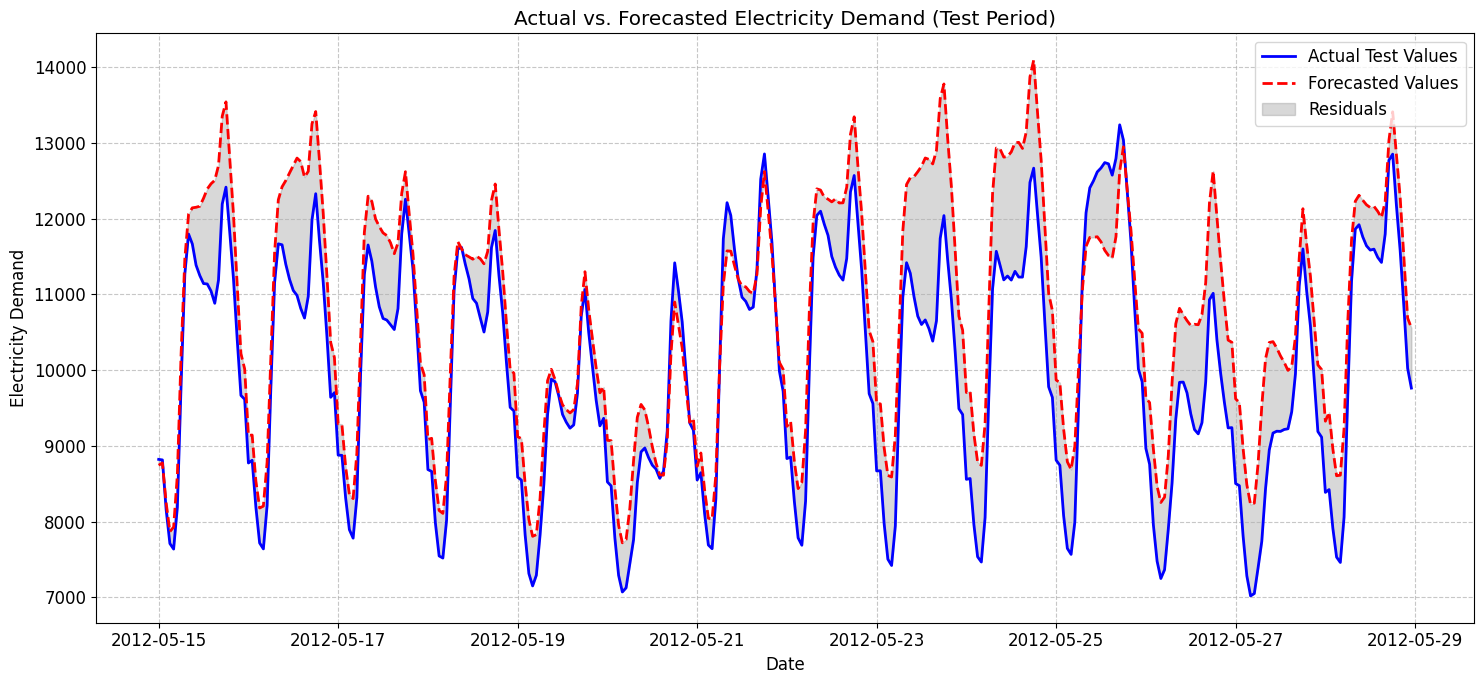

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(y_true.index, y_true, label='Actual Test Values', color='blue', linewidth=2)
plt.plot(y_pred.index, y_pred, label='Forecasted Values', color='red', linestyle='--', linewidth=2)
plt.fill_between(y_true.index, y_true, y_pred, color='gray', alpha=0.3, label='Residuals')

plt.title('Actual vs. Forecasted Electricity Demand (Test Period)')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("predicted.png")
plt.show()

### Rolling Forecast Errors

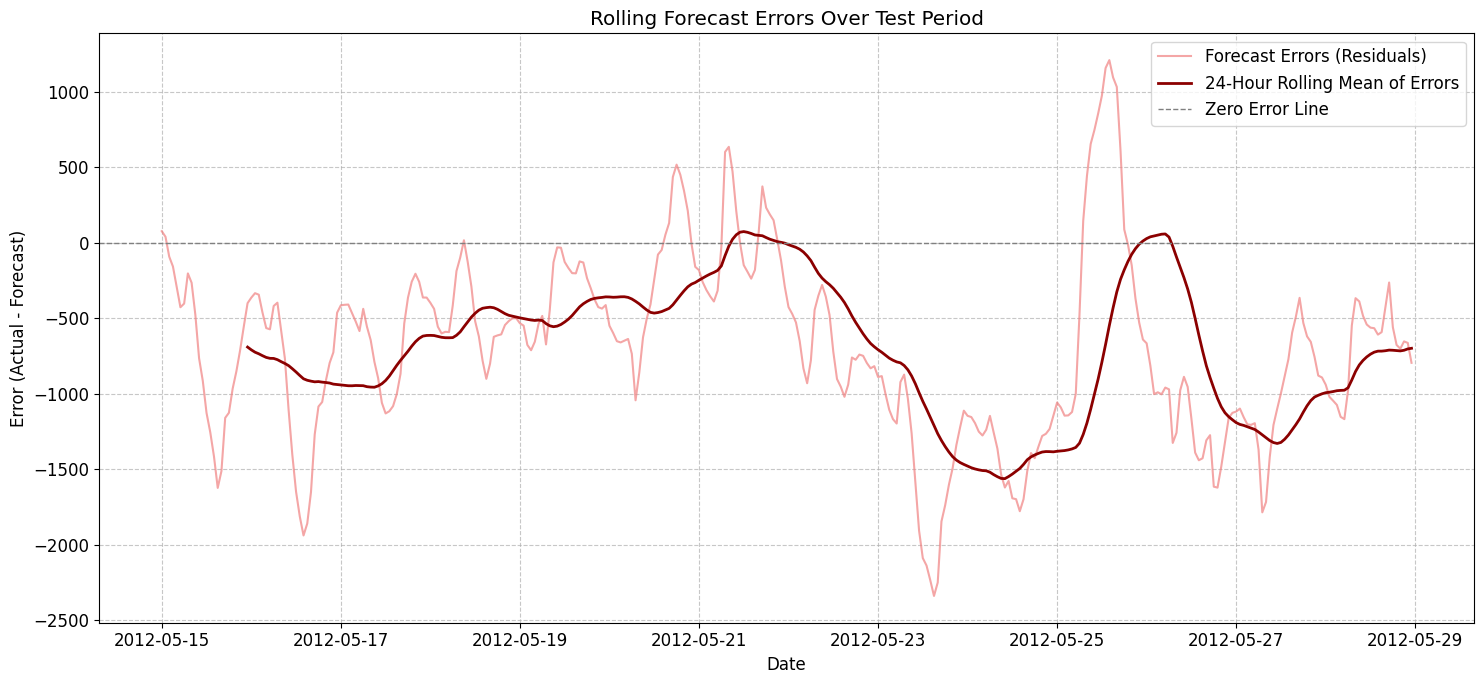

Summary statistics for residuals:


,0
count,336.000000
mean,-697.117743
std,600.303300
min,-2339.500273
25%,-1116.344650
50%,-654.237898
75%,-363.240461
max,1210.442572


In [ ]:
# Calculate residuals (forecast errors)
residuals = y_true - y_pred

# Calculate a rolling mean of the residuals for better visualization of trends
rolling_mean_residuals = residuals.rolling(window=24).mean() # 24-hour rolling mean

plt.figure(figsize=(15, 7))
plt.plot(residuals.index, residuals, label='Forecast Errors (Residuals)', color='lightcoral', alpha=0.7)
plt.plot(rolling_mean_residuals.index, rolling_mean_residuals, label='24-Hour Rolling Mean of Errors', color='darkred', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, label='Zero Error Line')

plt.title('Rolling Forecast Errors Over Test Period')
plt.xlabel('Date')
plt.ylabel('Error (Actual - Forecast)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Summary statistics for residuals:")
display(residuals.describe())

### Histogram of Forecast Residuals

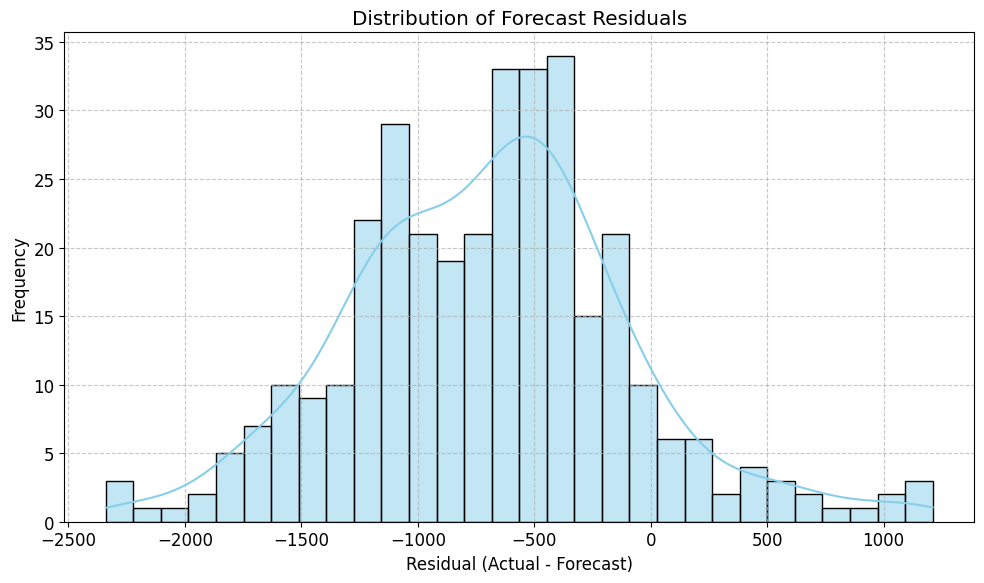

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='skyblue', bins=30)
plt.title('Distribution of Forecast Residuals')
plt.xlabel('Residual (Actual - Forecast)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Calculate Forecast Accuracy Metrics

We will use common metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) to evaluate the forecast accuracy on the test set.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ensure the forecast and test_data are aligned
y_true = test_data['y']
y_pred = final_forecast

# Calculate MAE
mae = mean_absolute_error(y_true, y_pred)

# Calculate MSE
mse = mean_squared_error(y_true, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAPE (handling zero values in y_true)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero by replacing zeros with a small epsilon or filtering
    return np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100

mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 781.94
Mean Squared Error (MSE): 845264.69
Root Mean Squared Error (RMSE): 919.38
Mean Absolute Percentage Error (MAPE): 7.99%
